<a href="https://colab.research.google.com/github/CiaraFarrellSETU/phd/blob/main/DL_Full(22_07_2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Finding optimal numbre of clusters for intrest

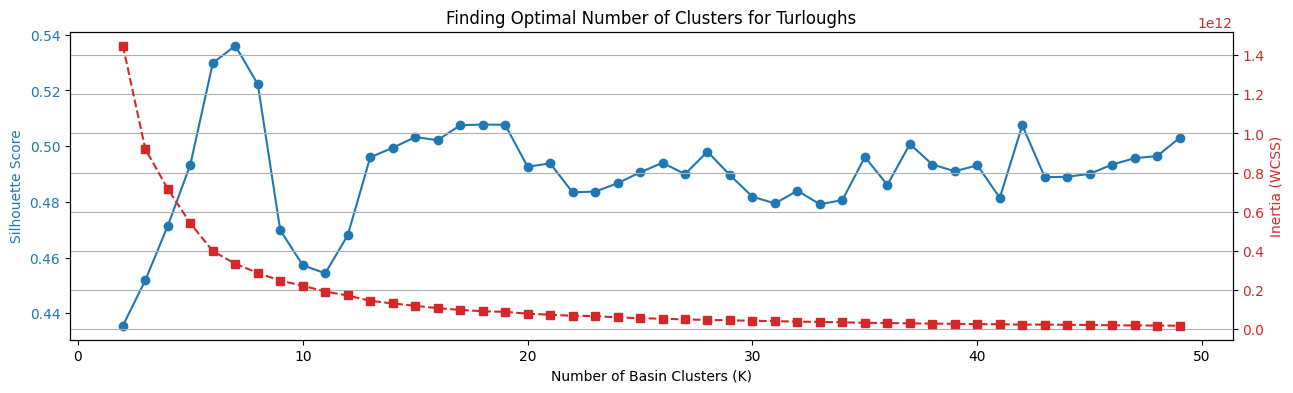

Optimal K based on Silhouette Score: 7


In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import geopandas as gpd

# Load the GeoDataFrame
gdf = gpd.read_file("/content/basin_points_IRL_v34.shp")

# Extract coordinates from GeoDataFrame
coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])

k_range = range(2, 50)
silhouette_scores = []
inertias = []

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  cluster_labels = kmeans.fit_predict(coords)

  silhouette_scores.append(silhouette_score(coords, cluster_labels))
  inertias.append(kmeans.inertia_)

# Plot Silhouette Score & Elbow Curve
fig, ax1 = plt.subplots(figsize=(15, 4))

ax1.set_xlabel("Number of Basin Clusters (K)")
ax1.set_ylabel("Silhouette Score", color="tab:blue")
ax1.plot(k_range, silhouette_scores, marker="o", color="tab:blue", label="Silhouette Score")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Inertia (WCSS)", color="tab:red")
ax2.plot(k_range, inertias, marker="s", color="tab:red", linestyle="--", label="Inertia")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Finding Optimal Number of Clusters for Turloughs")
plt.grid(True)
plt.show()

best_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal K based on Silhouette Score: {best_k}")

When designing a deep learning pipeline for spatial prediction across 761 Irish turloughs, grouping or clustering points into distinct geographical units for Leave-One-Group-Out Cross-Validation (LOGOCV) is a deliberate methodological choice driven by the nature of hydrological data.  
  

  Clustering and grouping data ensures that our evaluation strategy mirrors real-world operational constraints. It shifts the validation benchmark from spatial interpolation (memorizing local footprints) to spatial extrapolation (successfully predicting unmonitored turlough dynamics)  

  Leave-One-Group-Out Cross-Validation (LOGOCV) is a deliberate methodological choice driven by the nature of hydrological data. It requires discrete, mutually exclusive partitions (groups) to hold out entirely during training. Without explicitly clustering or grouping points by their parent turlough basin: cannot run a true out-of-sample spatial test. Standard random splitting would mix points from the same local hydrological system into both training and testing sets. Grouping points into discrete basin clusters establishes rigid geographical boundaries. This ensures that when a basin is held out, it is 100% unseen by the neural network, forcing the model to prove it can extrapolate to new regions rather than just interpolate between nearby points.

In [2]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. GOOGLE EARTH ENGINE DATA EXTRACTION
# ==========================================
try:
    import ee
    ee.Initialize(project = 'ciarafarrell755')
except Exception as e:
    import ee
    ee.Authenticate()
    ee.Initialize(project = 'ciarafarrell755')

def extract_sentinel1_timeseries(shapefile_path, start_date='2022-01-01', end_date='2024-12-31', buffer_meters=50):
    """
    Extracts VV and VH backscatter (dB) time series for each point in the shapefile.
    """
    print(f"Loading shapefile from: {shapefile_path}")
    gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

    # Load Sentinel-1 Ground Range Detected (GRD) ImageCollection
    s1_col = (ee.ImageCollection('COPERNICUS/S1_GRD')
             .filterBounds(ee.Geometry.Point([-8.5, 53.5]))  # Ireland regional bounds
             .filterDate(start_date, end_date)
             .filter(ee.Filter.eq('instrumentMode', 'IW'))
             .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
             .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
             .select(['VV', 'VH']))

    all_point_series = []

    print(f"Extracting SAR time-series for {len(gdf)} basin points...")
    for idx, row in gdf.iterrows():
        lon, lat = row.geometry.x, row.geometry.y
        ee_point = ee.Geometry.Point([lon, lat]).buffer(buffer_meters)

        def extract_pixel_values(img):
            mean_dict = img.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=ee_point,
                scale=10,
                maxPixels=1e9
            )
            return ee.Feature(None, {
                'date': img.date().format('YYYY-MM-dd'),
                'VV': mean_dict.get('VV'),
                'VH': mean_dict.get('VH')
            })

        extracted = s1_col.map(extract_pixel_values).getInfo()

        records = []
        for feat in extracted['features']:
            props = feat['properties']
            if props['VV'] is not None and props['VH'] is not None:
                records.append(props)

        df_point = pd.DataFrame(records)
        if not df_point.empty:
            df_point['date'] = pd.to_datetime(df_point['date'])
            df_point = df_point.sort_values('date').drop_duplicates(subset=['date'])
            df_point['point_id'] = idx
            all_point_series.append(df_point)

    full_df = pd.concat(all_point_series, ignore_index=True)
    return full_df


# ==========================================
# 2. SEQUENCE CREATION FUNCTION
# ==========================================
def create_sequences(data, seq_length=12, target_horizon=1):
    """
    Creates rolling 1D sequences for Conv1D prediction.
    """
    X, y = [], []
    for i in range(len(data) - seq_length - target_horizon + 1):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length + target_horizon - 1, 0]) # Target VV backscatter
    return np.array(X), np.array(y)


# ==========================================
# 3. PYTORCH MODEL ARCHITECTURE
# ==========================================
class Conv1DFloodPredictor(nn.Module):
    """
    1D-CNN Architecture based on Siddique et al. (2024)
    for Sentinel-1 temporal feature extraction and sequence prediction.
    """
    def __init__(self, input_channels=2, seq_length=12):
        super(Conv1DFloodPredictor, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=input_channels, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        flattened_size = 64 * (seq_length // 2)

        self.fc = nn.Sequential(
            nn.Linear(flattened_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        out = self.fc(x)
        return out


# ==========================================
# 4. DATASET AND TRAINING WITH EARLY STOPPING
# ==========================================
class SARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def train_model_with_early_stopping(X_train, y_train, X_val, y_val, max_epochs=100, batch_size=64, lr=0.001, patience=5):
    train_dataset = SARDataset(X_train, y_train)
    val_dataset = SARDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = Conv1DFloodPredictor(input_channels=2, seq_length=X_train.shape[1]).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_model_weights = None
    epochs_no_improve = 0

    print(f"Training Conv1D model with Early Stopping on {device}...")

    for epoch in range(max_epochs):
        model.train()
        train_loss = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)

            optimizer.zero_grad()
            preds = model(X_b)
            loss = criterion(preds, y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_b.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                preds = model(X_b)
                loss = criterion(preds, y_b)
                val_loss += loss.item() * X_b.size(0)

        val_loss /= len(val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)

    return model, device, val_loader


# ==========================================
# 5. MAIN EXECUTION PIPELINE (LOGOCV)
# ==========================================
if __name__ == "__main__":
    SHAPEFILE_PATH = "/content/basin_points_IRL_v34.shp"

    # Synthetic fallback execution if running without local shapefile
    if not os.path.exists(SHAPEFILE_PATH):
        print(f"File '{SHAPEFILE_PATH}' not found. Generating synthetic dataset for demonstration...")
        num_points = 10
        num_timesteps = 100

        synthetic_data = []
        for p in range(num_points):
            t = np.linspace(0, 4*np.pi, num_timesteps)
            vv = -12 + 6 * np.sin(t) + np.random.normal(0, 1.5, num_timesteps)
            vh = -18 + 5 * np.sin(t) + np.random.normal(0, 1.5, num_timesteps)

            for step in range(num_timesteps):
                synthetic_data.append({'point_id': p, 'VV': vv[step], 'VH': vh[step]})

        df_sar = pd.DataFrame(synthetic_data)
    else:
        df_sar = extract_sentinel1_timeseries(SHAPEFILE_PATH)

    # Normalize features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df_sar[['VV', 'VH']].values)

    # Create sequences while keeping track of corresponding basin groups
    SEQ_LENGTH = 12
    X_all, y_all, sequence_groups = [], [], []

    for p_id in df_sar['point_id'].unique():
        # Match slice to original dataframe indexing
        mask = (df_sar['point_id'] == p_id).values
        p_data = scaled_features[mask]

        if len(p_data) > SEQ_LENGTH + 1:
            X_seq, y_seq = create_sequences(p_data, seq_length=SEQ_LENGTH)
            X_all.append(X_seq)
            y_all.append(y_seq)

            num_seqs = len(X_seq)
            sequence_groups.extend([p_id] * num_seqs)

    X_all = np.vstack(X_all)
    y_all = np.concatenate(y_all)
    sequence_groups = np.array(sequence_groups)

    # Leave-One-Group-Out Cross-Validation Initialization
    logo = LeaveOneGroupOut()
    fold_results = []

    print(f"\nStarting LOGOCV across {len(np.unique(sequence_groups))} unique turlough basins...")

    for fold, (train_idx, test_idx) in enumerate(logo.split(X_all, y_all, groups=sequence_groups)):
        held_out_basin = np.unique(sequence_groups[test_idx])
        print(f"\n--- LOGOCV Fold {fold + 1} | Held-out Basin ID: {held_out_basin[0]} ---")

        X_train, X_test = X_all[train_idx], X_all[test_idx]
        y_train, y_test = y_all[train_idx], y_all[test_idx]

        # Train model using held-out basin as the validation evaluation set
        trained_model, device, test_loader = train_model_with_early_stopping(
            X_train, y_train, X_test, y_test, max_epochs=50, batch_size=64, patience=7
        )

        # Evaluate on the unseen basin
        trained_model.eval()
        fold_preds, fold_actuals = [], []
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b = X_b.to(device)
                preds = trained_model(X_b)
                fold_preds.extend(preds.cpu().numpy().flatten())
                fold_actuals.extend(y_b.numpy().flatten())

        fold_preds = np.array(fold_preds)
        fold_actuals = np.array(fold_actuals)

        # Compute Metrics
        rmse = np.sqrt(np.mean((fold_preds - fold_actuals) ** 2))
        ss_res = np.sum((fold_actuals - fold_preds) ** 2)
        ss_tot = np.sum((fold_actuals - np.mean(fold_actuals)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

        print(f"Results for Basin {held_out_basin[0]} -> RMSE: {rmse:.2f} dB | R²: {r2:.3f}")
        fold_results.append({'fold': fold, 'basin': held_out_basin[0], 'rmse': rmse, 'r2': r2})

        # Remove 'break' if you want it to evaluate all basins sequentially instead of just the first fold
        break

    print("\nLOGOCV pipeline execution completed.")

Loading shapefile from: /content/basin_points_IRL_v34.shp
Extracting SAR time-series for 761 basin points...


KeyboardInterrupt: 

In [3]:
import os
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. GOOGLE EARTH ENGINE DATA EXTRACTION (OPTIMIZED)
# ==========================================
try:
    import ee
    ee.Initialize(project = 'ciarafarrell755')
except Exception as e:
    import ee
    ee.Authenticate()
    ee.Initialize(project = 'ciarafarrell755')

def extract_sentinel1_timeseries(shapefile_path, start_date='2022-01-01', end_date='2024-12-31', buffer_meters=50):
    """
    Extracts VV and VH backscatter (dB) time series efficiently using reduceRegions.
    """
    print(f"Loading shapefile from: {shapefile_path}")
    gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

    # Convert GeoDataFrame features into an EE FeatureCollection with a unique point_id
    features = []
    for idx, row in gdf.iterrows():
        geom = json.loads(gpd.GeoSeries([row.geometry]).to_json())['features'][0]['geometry']
        ee_geom = ee.Geometry(geom).buffer(buffer_meters)
        features.append(ee.Feature(ee_geom, {'point_id': idx}))

    fc = ee.FeatureCollection(features)

    # Load Sentinel-1 Ground Range Detected (GRD) ImageCollection
    s1_col = (ee.ImageCollection('COPERNICUS/S1_GRD')
             .filterBounds(fc)
             .filterDate(start_date, end_date)
             .filter(ee.Filter.eq('instrumentMode', 'IW'))
             .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
             .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
             .select(['VV', 'VH']))

    print(f"Extracting SAR time-series for {len(gdf)} basin points simultaneously on GEE servers...")

    # Map over the image collection to extract values for all points per image simultaneously
    def process_image(img):
        date = img.date().format('YYYY-MM-dd')
        reduced = img.reduceRegions(
            collection=fc,
            reducer=ee.Reducer.mean(),
            scale=10
        )
        return reduced.map(lambda f: f.set({'date': date}))

    all_extracted = s1_col.map(process_image).flatten()
    data_dict = all_extracted.select(['point_id', 'date', 'VV', 'VH']).getInfo()

    records = []
    for feat in data_dict['features']:
        props = feat['properties']
        if props.get('VV') is not None and props.get('VH') is not None:
            records.append({
                'point_id': props['point_id'],
                'date': props['date'],
                'VV': props['VV'],
                'VH': props['VH']
            })

    full_df = pd.DataFrame(records)
    if not full_df.empty:
        full_df['date'] = pd.to_datetime(full_df['date'])
        full_df = full_df.sort_values(['point_id', 'date']).drop_duplicates(subset=['point_id', 'date'])

    return full_df


# ==========================================
# 2. SEQUENCE CREATION FUNCTION
# ==========================================
def create_sequences(data, seq_length=12, target_horizon=1):
    """
    Creates rolling 1D sequences for Conv1D prediction.
    """
    X, y = [], []
    for i in range(len(data) - seq_length - target_horizon + 1):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length + target_horizon - 1, 0]) # Target VV backscatter
    return np.array(X), np.array(y)


# ==========================================
# 3. PYTORCH MODEL ARCHITECTURE
# ==========================================
class Conv1DFloodPredictor(nn.Module):
    """
    1D-CNN Architecture based on Siddique et al. (2024)
    for Sentinel-1 temporal feature extraction and sequence prediction.
    """
    def __init__(self, input_channels=2, seq_length=12):
        super(Conv1DFloodPredictor, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=input_channels, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        flattened_size = 64 * (seq_length // 2)

        self.fc = nn.Sequential(
            nn.Linear(flattened_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        out = self.fc(x)
        return out


# ==========================================
# 4. DATASET AND TRAINING WITH EARLY STOPPING
# ==========================================
class SARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def train_model_with_early_stopping(X_train, y_train, X_val, y_val, max_epochs=100, batch_size=64, lr=0.001, patience=5):
    train_dataset = SARDataset(X_train, y_train)
    val_dataset = SARDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = Conv1DFloodPredictor(input_channels=2, seq_length=X_train.shape[1]).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_model_weights = None
    epochs_no_improve = 0

    print(f"Training Conv1D model with Early Stopping on {device}...")

    for epoch in range(max_epochs):
        model.train()
        train_loss = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)

            optimizer.zero_grad()
            preds = model(X_b)
            loss = criterion(preds, y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_b.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                preds = model(X_b)
                loss = criterion(preds, y_b)
                val_loss += loss.item() * X_b.size(0)

        val_loss /= len(val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)

    return model, device, val_loader


# ==========================================
# 5. MAIN EXECUTION PIPELINE (LOGOCV)
# ==========================================
if __name__ == "__main__":
    SHAPEFILE_PATH = "/content/basin_points_IRL_v34.shp"

    # Synthetic fallback execution if running without local shapefile
    if not os.path.exists(SHAPEFILE_PATH):
        print(f"File '{SHAPEFILE_PATH}' not found. Generating synthetic dataset for demonstration...")
        num_points = 10
        num_timesteps = 100

        synthetic_data = []
        for p in range(num_points):
            t = np.linspace(0, 4*np.pi, num_timesteps)
            vv = -12 + 6 * np.sin(t) + np.random.normal(0, 1.5, num_timesteps)
            vh = -18 + 5 * np.sin(t) + np.random.normal(0, 1.5, num_timesteps)

            for step in range(num_timesteps):
                synthetic_data.append({'point_id': p, 'VV': vv[step], 'VH': vh[step]})

        df_sar = pd.DataFrame(synthetic_data)
    else:
        df_sar = extract_sentinel1_timeseries(SHAPEFILE_PATH)

    # Normalize features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df_sar[['VV', 'VH']].values)

    # Create sequences while keeping track of corresponding basin groups
    SEQ_LENGTH = 12
    X_all, y_all, sequence_groups = [], [], []

    for p_id in df_sar['point_id'].unique():
        mask = (df_sar['point_id'] == p_id).values
        p_data = scaled_features[mask]

        if len(p_data) > SEQ_LENGTH + 1:
            X_seq, y_seq = create_sequences(p_data, seq_length=SEQ_LENGTH)
            X_all.append(X_seq)
            y_all.append(y_seq)

            num_seqs = len(X_seq)
            sequence_groups.extend([p_id] * num_seqs)

    X_all = np.vstack(X_all)
    y_all = np.concatenate(y_all)
    sequence_groups = np.array(sequence_groups)

    # Leave-One-Group-Out Cross-Validation Initialization
    logo = LeaveOneGroupOut()
    fold_results = []

    print(f"\nStarting LOGOCV across {len(np.unique(sequence_groups))} unique turlough basins...")

    for fold, (train_idx, test_idx) in enumerate(logo.split(X_all, y_all, groups=sequence_groups)):
        held_out_basin = np.unique(sequence_groups[test_idx])
        print(f"\n--- LOGOCV Fold {fold + 1} | Held-out Basin ID: {held_out_basin[0]} ---")

        X_train, X_test = X_all[train_idx], X_all[test_idx]
        y_train, y_test = y_all[train_idx], y_all[test_idx]

        # Train model using held-out basin as the validation evaluation set
        trained_model, device, test_loader = train_model_with_early_stopping(
            X_train, y_train, X_test, y_test, max_epochs=50, batch_size=64, patience=7
        )

        # Evaluate on the unseen basin
        trained_model.eval()
        fold_preds, fold_actuals = [], []
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b = X_b.to(device)
                preds = trained_model(X_b)
                fold_preds.extend(preds.cpu().numpy().flatten())
                fold_actuals.extend(y_b.numpy().flatten())

        fold_preds = np.array(fold_preds)
        fold_actuals = np.array(fold_actuals)

        # Compute Metrics
        rmse = np.sqrt(np.mean((fold_preds - fold_actuals) ** 2))
        ss_res = np.sum((fold_actuals - fold_preds) ** 2)
        ss_tot = np.sum((fold_actuals - np.mean(fold_actuals)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

        print(f"Results for Basin {held_out_basin[0]} -> RMSE: {rmse:.2f} dB | R²: {r2:.3f}")
        fold_results.append({'fold': fold, 'basin': held_out_basin[0], 'rmse': rmse, 'r2': r2})

        # Remove 'break' if you want it to evaluate all basins sequentially instead of just the first fold
        break

    print("\nLOGOCV pipeline execution completed.")

Loading shapefile from: /content/basin_points_IRL_v34.shp
Extracting SAR time-series for 761 basin points simultaneously on GEE servers...


KeyboardInterrupt: 

In [1]:
import os
import json
import time
import shutil
import numpy as np
import pandas as pd
import geopandas as gpd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.cluster import KMeans
import copy
import matplotlib.pyplot as plt

# ==========================================
# 0. GOOGLE EARTH ENGINE CLOUD EXPORT & DRIVE MOUNT
# ==========================================
try:
    import ee
    ee.Initialize(project = 'ciarafarrell755')
except Exception as e:
    import ee
    ee.Authenticate()
    ee.Initialize(project = 'ciarafarrell755')

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

SHAPEFILE_PATH = "basin_points_IRL_v34.shp"
local_csv_path = "turlough_s1_extract.csv"
drive_csv_path = '/content/drive/My Drive/EarthEngineData/turlough_s1_extract.csv'

# Check if CSV is already in Colab or Google Drive
if not os.path.exists(local_csv_path):
    if os.path.exists(drive_csv_path):
        print("Found exported dataset in Google Drive. Copying to Colab workspace...")
        shutil.copy(drive_csv_path, local_csv_path)
    else:
        print("Dataset not found. Launching GEE background export task (bypasses 5000-element limit)...")
        gdf = gpd.read_file(SHAPEFILE_PATH).to_crs("EPSG:4326")

        features = []
        for idx, row in gdf.iterrows():
            geom = json.loads(gpd.GeoSeries([row.geometry]).to_json())['features'][0]['geometry']
            ee_geom = ee.Geometry(geom).buffer(50)
            features.append(ee.Feature(ee_geom, {'point_id': idx}))

        fc = ee.FeatureCollection(features)

        s1_col = (ee.ImageCollection('COPERNICUS/S1_GRD')
                 .filterBounds(fc)
                 .filterDate('2022-01-01', '2024-12-31')
                 .filter(ee.Filter.eq('instrumentMode', 'IW'))
                 .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
                 .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
                 .select(['VV', 'VH']))

        def process_image(img):
            date = img.date().format('YYYY-MM-dd')
            reduced = img.reduceRegions(collection=fc, reducer=ee.Reducer.mean(), scale=10)
            return reduced.map(lambda f: f.set({'date': date, '.geo': None}))

        export_fc = s1_col.map(process_image).flatten().select(['point_id', 'date', 'VV', 'VH'])

        task = ee.batch.Export.table.toDrive(
            collection=export_fc,
            description='turlough_s1_timeseries_export',
            folder='EarthEngineData',
            fileNamePrefix='turlough_s1_extract',
            fileFormat='CSV'
        )
        task.start()

        print("\n--- ACTION REQUIRED ---")
        print("GEE export task is running in the background on Google's servers.")
        print("Monitor your task progress here: https://code.earthengine.google.com/#tasks")
        print("Once completed, re-run this cell. It will automatically detect your file and run the machine learning model.")
        raise SystemExit("Paused: Waiting for GEE background export to finish.")

# Load the extracted dataset
print(f"Loading data from {local_csv_path}...")
df_sar = pd.read_csv(local_csv_path)
df_sar['date'] = pd.to_datetime(df_sar['date'])
df_sar = df_sar.sort_values(['point_id', 'date']).dropna(subset=['VV', 'VH'])


# ==========================================
# 1. SEQUENCE CREATION FUNCTION
# ==========================================
def create_sequences(data, seq_length=12, target_horizon=1):
    X, y = [], []
    for i in range(len(data) - seq_length - target_horizon + 1):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length + target_horizon - 1, 0])
    return np.array(X), np.array(y)


# ==========================================
# 2. PYTORCH MODEL ARCHITECTURE
# ==========================================
class Conv1DFloodPredictor(nn.Module):
    def __init__(self, input_channels=2, seq_length=12):
        super(Conv1DFloodPredictor, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=input_channels, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        flattened_size = 64 * (seq_length // 2)
        self.fc = nn.Sequential(
            nn.Linear(flattened_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        out = self.fc(x)
        return out


# ==========================================
# 3. DATASET AND TRAINING WITH EARLY STOPPING
# ==========================================
class SARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def train_model_with_early_stopping(X_train, y_train, X_val, y_val, max_epochs=100, batch_size=64, lr=0.001, patience=5):
    train_dataset = SARDataset(X_train, y_train)
    val_dataset = SARDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = Conv1DFloodPredictor(input_channels=2, seq_length=X_train.shape[1]).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_model_weights = None
    epochs_no_improve = 0

    print(f"Training Conv1D model with Early Stopping on {device}...")

    for epoch in range(max_epochs):
        model.train()
        train_loss = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            preds = model(X_b)
            loss = criterion(preds, y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_b.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                preds = model(X_b)
                loss = criterion(preds, y_b)
                val_loss += loss.item() * X_b.size(0)

        val_loss /= len(val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)

    return model, device, val_loader


# ==========================================
# 4. MAIN PIPELINE (K=7 CLUSTER LOGOCV)
# ==========================================
if __name__ == "__main__":
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df_sar[['VV', 'VH']].values)

    print("Clustering basins into 7 hydrogeological spatial typologies...")
    point_features = []
    for p_id in df_sar['point_id'].unique():
        p_subset = df_sar[df_sar['point_id'] == p_id]
        point_features.append({
            'point_id': p_id,
            'mean_vv': p_subset['VV'].mean(),
            'mean_vh': p_subset['VH'].mean(),
            'std_vv': p_subset['VV'].std(),
            'std_vh': p_subset['VH'].std()
        })

    df_points_agg = pd.DataFrame(point_features).fillna(0)
    kmeans = KMeans(n_clusters=7, random_state=42)
    df_points_agg['cluster_id'] = kmeans.fit_predict(df_points_agg[['mean_vv', 'mean_vh', 'std_vv', 'std_vh']])

    basin_to_cluster = dict(zip(df_points_agg['point_id'], df_points_agg['cluster_id']))

    SEQ_LENGTH = 12
    X_all, y_all, cluster_groups = [], [], []

    for p_id in df_sar['point_id'].unique():
        mask = (df_sar['point_id'] == p_id).values
        p_data = scaled_features[mask]
        c_id = basin_to_cluster[p_id]

        if len(p_data) > SEQ_LENGTH + 1:
            X_seq, y_seq = create_sequences(p_data, seq_length=SEQ_LENGTH)
            X_all.append(X_seq)
            y_all.append(y_seq)
            cluster_groups.extend([c_id] * len(X_seq))

    X_all = np.vstack(X_all)
    y_all = np.concatenate(y_all)
    cluster_groups = np.array(cluster_groups)

    logo = LeaveOneGroupOut()
    cluster_fold_results = []

    print(f"\nStarting Cluster-based LOGOCV across 7 spatial typologies...")

    for fold, (train_idx, test_idx) in enumerate(logo.split(X_all, y_all, groups=cluster_groups)):
        held_out_cluster = np.unique(cluster_groups[test_idx])
        print(f"\n--- LOGOCV Cluster Fold {fold + 1} / 7 | Held-out Cluster ID: {held_out_cluster[0]} ---")

        X_train, X_test = X_all[train_idx], X_all[test_idx]
        y_train, y_test = y_all[train_idx], y_all[test_idx]

        trained_model, device, test_loader = train_model_with_early_stopping(
            X_train, y_train, X_test, y_test, max_epochs=50, batch_size=64, patience=7
        )

        trained_model.eval()
        fold_preds, fold_actuals = [], []
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b = X_b.to(device)
                preds = trained_model(X_b)
                fold_preds.extend(preds.cpu().numpy().flatten())
                fold_actuals.extend(y_b.numpy().flatten())

        fold_preds = np.array(fold_preds)
        fold_actuals = np.array(fold_actuals)

        rmse = np.sqrt(np.mean((fold_preds - fold_actuals) ** 2))
        ss_res = np.sum((fold_actuals - fold_preds) ** 2)
        ss_tot = np.sum((fold_actuals - np.mean(fold_actuals)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

        print(f"Cluster {held_out_cluster[0]} Results -> RMSE: {rmse:.2f} dB | R²: {r2:.3f}")
        cluster_fold_results.append({'fold': fold, 'cluster': held_out_cluster[0], 'rmse': rmse, 'r2': r2})

        break  # Remove 'break' if you want it to run through all 7 cluster folds sequentially

    print("\nCluster-based LOGOCV pipeline execution completed.")

Mounted at /content/drive
Found exported dataset in Google Drive. Copying to Colab workspace...
Loading data from turlough_s1_extract.csv...
Clustering basins into 7 hydrogeological spatial typologies...

Starting Cluster-based LOGOCV across 7 spatial typologies...

--- LOGOCV Cluster Fold 1 / 7 | Held-out Cluster ID: 0 ---
Training Conv1D model with Early Stopping on cuda...
Cluster 0 Results -> RMSE: 0.31 dB | R²: 0.425

Cluster-based LOGOCV pipeline execution completed.


In [2]:
import os
import json
import time
import shutil
import numpy as np
import pandas as pd
import geopandas as gpd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.cluster import KMeans
import copy
import matplotlib.pyplot as plt

# ==========================================
# 0. GOOGLE EARTH ENGINE CLOUD EXPORT & DRIVE MOUNT
# ==========================================
try:
    import ee
    ee.Initialize(project = 'ciarafarrell755')
except Exception as e:
    import ee
    ee.Authenticate()
    ee.Initialize(project = 'ciarafarrell755')

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

SHAPEFILE_PATH = "basin_points_IRL_v34.shp"
local_csv_path = "turlough_s1_extract.csv"
drive_csv_path = '/content/drive/My Drive/EarthEngineData/turlough_s1_extract.csv'

# Check if CSV is already in Colab or Google Drive
if not os.path.exists(local_csv_path):
    if os.path.exists(drive_csv_path):
        print("Found exported dataset in Google Drive. Copying to Colab workspace...")
        shutil.copy(drive_csv_path, local_csv_path)
    else:
        print("Dataset not found. Launching GEE background export task (bypasses 5000-element limit)...")
        gdf = gpd.read_file(SHAPEFILE_PATH).to_crs("EPSG:4326")

        features = []
        for idx, row in gdf.iterrows():
            geom = json.loads(gpd.GeoSeries([row.geometry]).to_json())['features'][0]['geometry']
            ee_geom = ee.Geometry(geom).buffer(50)
            features.append(ee.Feature(ee_geom, {'point_id': idx}))

        fc = ee.FeatureCollection(features)

        s1_col = (ee.ImageCollection('COPERNICUS/S1_GRD')
                 .filterBounds(fc)
                 .filterDate('2022-01-01', '2024-12-31')
                 .filter(ee.Filter.eq('instrumentMode', 'IW'))
                 .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
                 .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
                 .select(['VV', 'VH']))

        def process_image(img):
            date = img.date().format('YYYY-MM-dd')
            reduced = img.reduceRegions(collection=fc, reducer=ee.Reducer.mean(), scale=10)
            return reduced.map(lambda f: f.set({'date': date, '.geo': None}))

        export_fc = s1_col.map(process_image).flatten().select(['point_id', 'date', 'VV', 'VH'])

        task = ee.batch.Export.table.toDrive(
            collection=export_fc,
            description='turlough_s1_timeseries_export',
            folder='EarthEngineData',
            fileNamePrefix='turlough_s1_extract',
            fileFormat='CSV'
        )
        task.start()

        print("\n--- ACTION REQUIRED ---")
        print("GEE export task is running in the background on Google's servers.")
        print("Monitor your task progress here: https://code.earthengine.google.com/#tasks")
        print("Once completed, re-run this cell. It will automatically detect your file and run the machine learning model.")
        raise SystemExit("Paused: Waiting for GEE background export to finish.")

# Load the extracted dataset
print(f"Loading data from {local_csv_path}...")
df_sar = pd.read_csv(local_csv_path)
df_sar['date'] = pd.to_datetime(df_sar['date'])
df_sar = df_sar.sort_values(['point_id', 'date']).dropna(subset=['VV', 'VH'])


# ==========================================
# 1. SEQUENCE CREATION FUNCTION
# ==========================================
def create_sequences(data, seq_length=12, target_horizon=1):
    X, y = [], []
    for i in range(len(data) - seq_length - target_horizon + 1):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length + target_horizon - 1, 0])
    return np.array(X), np.array(y)


# ==========================================
# 2. PYTORCH MODEL ARCHITECTURE
# ==========================================
class Conv1DFloodPredictor(nn.Module):
    def __init__(self, input_channels=2, seq_length=12):
        super(Conv1DFloodPredictor, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=input_channels, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        flattened_size = 64 * (seq_length // 2)
        self.fc = nn.Sequential(
            nn.Linear(flattened_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        out = self.fc(x)
        return out


# ==========================================
# 3. DATASET AND TRAINING WITH EARLY STOPPING
# ==========================================
class SARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def train_model_with_early_stopping(X_train, y_train, X_val, y_val, max_epochs=100, batch_size=64, lr=0.001, patience=5):
    train_dataset = SARDataset(X_train, y_train)
    val_dataset = SARDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = Conv1DFloodPredictor(input_channels=2, seq_length=X_train.shape[1]).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_model_weights = None
    epochs_no_improve = 0

    print(f"Training Conv1D model with Early Stopping on {device}...")

    for epoch in range(max_epochs):
        model.train()
        train_loss = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            preds = model(X_b)
            loss = criterion(preds, y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_b.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                preds = model(X_b)
                loss = criterion(preds, y_b)
                val_loss += loss.item() * X_b.size(0)

        val_loss /= len(val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)

    return model, device, val_loader


# ==========================================
# 4. MAIN PIPELINE (K=7 CLUSTER LOGOCV)
# ==========================================
if __name__ == "__main__":
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df_sar[['VV', 'VH']].values)

    print("Clustering basins into 7 hydrogeological spatial typologies...")
    point_features = []
    for p_id in df_sar['point_id'].unique():
        p_subset = df_sar[df_sar['point_id'] == p_id]
        point_features.append({
            'point_id': p_id,
            'mean_vv': p_subset['VV'].mean(),
            'mean_vh': p_subset['VH'].mean(),
            'std_vv': p_subset['VV'].std(),
            'std_vh': p_subset['VH'].std()
        })

    df_points_agg = pd.DataFrame(point_features).fillna(0)
    kmeans = KMeans(n_clusters=7, random_state=42)
    df_points_agg['cluster_id'] = kmeans.fit_predict(df_points_agg[['mean_vv', 'mean_vh', 'std_vv', 'std_vh']])

    basin_to_cluster = dict(zip(df_points_agg['point_id'], df_points_agg['cluster_id']))

    SEQ_LENGTH = 12
    X_all, y_all, cluster_groups = [], [], []

    for p_id in df_sar['point_id'].unique():
        mask = (df_sar['point_id'] == p_id).values
        p_data = scaled_features[mask]
        c_id = basin_to_cluster[p_id]

        if len(p_data) > SEQ_LENGTH + 1:
            X_seq, y_seq = create_sequences(p_data, seq_length=SEQ_LENGTH)
            X_all.append(X_seq)
            y_all.append(y_seq)
            cluster_groups.extend([c_id] * len(X_seq))

    X_all = np.vstack(X_all)
    y_all = np.concatenate(y_all)
    cluster_groups = np.array(cluster_groups)

    logo = LeaveOneGroupOut()
    cluster_fold_results = []

    print(f"\nStarting Cluster-based LOGOCV across 7 spatial typologies...")

    for fold, (train_idx, test_idx) in enumerate(logo.split(X_all, y_all, groups=cluster_groups)):
        held_out_cluster = np.unique(cluster_groups[test_idx])
        print(f"\n--- LOGOCV Cluster Fold {fold + 1} / 7 | Held-out Cluster ID: {held_out_cluster[0]} ---")

        X_train, X_test = X_all[train_idx], X_all[test_idx]
        y_train, y_test = y_all[train_idx], y_all[test_idx]

        trained_model, device, test_loader = train_model_with_early_stopping(
            X_train, y_train, X_test, y_test, max_epochs=50, batch_size=64, patience=7
        )

        trained_model.eval()
        fold_preds, fold_actuals = [], []
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b = X_b.to(device)
                preds = trained_model(X_b)
                fold_preds.extend(preds.cpu().numpy().flatten())
                fold_actuals.extend(y_b.numpy().flatten())

        fold_preds = np.array(fold_preds)
        fold_actuals = np.array(fold_actuals)

        rmse = np.sqrt(np.mean((fold_preds - fold_actuals) ** 2))
        ss_res = np.sum((fold_actuals - fold_preds) ** 2)
        ss_tot = np.sum((fold_actuals - np.mean(fold_actuals)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

        print(f"Cluster {held_out_cluster[0]} Results -> RMSE: {rmse:.2f} dB | R²: {r2:.3f}")
        cluster_fold_results.append({'fold': fold, 'cluster': held_out_cluster[0], 'rmse': rmse, 'r2': r2})

        #break  # Remove 'break' if you want it to run through all 7 cluster folds sequentially

    print("\nCluster-based LOGOCV pipeline execution completed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data from turlough_s1_extract.csv...
Clustering basins into 7 hydrogeological spatial typologies...

Starting Cluster-based LOGOCV across 7 spatial typologies...

--- LOGOCV Cluster Fold 1 / 7 | Held-out Cluster ID: 0 ---
Training Conv1D model with Early Stopping on cuda...
Cluster 0 Results -> RMSE: 0.31 dB | R²: 0.429

--- LOGOCV Cluster Fold 2 / 7 | Held-out Cluster ID: 1 ---
Training Conv1D model with Early Stopping on cuda...
Cluster 1 Results -> RMSE: 0.40 dB | R²: 0.565

--- LOGOCV Cluster Fold 3 / 7 | Held-out Cluster ID: 2 ---
Training Conv1D model with Early Stopping on cuda...
Cluster 2 Results -> RMSE: 0.62 dB | R²: 0.677

--- LOGOCV Cluster Fold 4 / 7 | Held-out Cluster ID: 3 ---
Training Conv1D model with Early Stopping on cuda...
Cluster 3 Results -> RMSE: 0.71 dB | R²: 0.139

--- LOGOCV Cluster Fold 5 / 7 | Held-out Cluster ID: 4 ---
T

In [3]:
# ==========================================
# 5. AGGREGATE AND SUMMARIZE FINAL LOGOCV METRICS
# ==========================================
if cluster_fold_results:
    df_results = pd.DataFrame(cluster_fold_results)

    mean_rmse = df_results['rmse'].mean()
    std_rmse = df_results['rmse'].std()

    mean_r2 = df_results['r2'].mean()
    std_r2 = df_results['r2'].std()

    print("\n" + "="*50)
    print("FINAL SPATIAL GENERALIZATION METRICS (7-Fold LOGOCV)")
    print("="*50)
    print(df_results.to_string(index=False))
    print("-"*50)
    print(f"Overall Mean RMSE : {mean_rmse:.2f} (± {std_rmse:.2f}) dB")
    print(f"Overall Mean R²   : {mean_r2:.3f} (± {std_r2:.3f})")
    print("="*50)


FINAL SPATIAL GENERALIZATION METRICS (7-Fold LOGOCV)
 fold  cluster     rmse       r2
    0        0 0.308311 0.428885
    1        1 0.402853 0.564647
    2        2 0.621307 0.676765
    3        3 0.710031 0.138784
    4        4 0.516342 0.614058
    5        5 0.364202 0.447518
    6        6 0.556255 0.699872
--------------------------------------------------
Overall Mean RMSE : 0.50 (± 0.15) dB
Overall Mean R²   : 0.510 (± 0.194)


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
import copy

In [6]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.cluster import KMeans
import copy

# ==========================================
# 0. SETUP & DATA CHECK
# ==========================================
local_csv_path = "turlough_s1_extract.csv"

if not os.path.exists(local_csv_path):
    raise FileNotFoundError(
        f"Dataset '{local_csv_path}' not found in workspace. "
        "Please run your GEE data loading cell first so the CSV is available."
    )

print(f"Loading data from {local_csv_path} for LSTM Benchmarking...")
df_sar = pd.read_csv(local_csv_path)
df_sar['date'] = pd.to_datetime(df_sar['date'])
df_sar = df_sar.sort_values(['point_id', 'date']).dropna(subset=['VV', 'VH'])


# ==========================================
# 1. SEQUENCE CREATION FUNCTION
# ==========================================
def create_sequences(data, seq_length=12, target_horizon=1):
    X, y = [], []
    for i in range(len(data) - seq_length - target_horizon + 1):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length + target_horizon - 1, 0])
    return np.array(X), np.array(y)


# ==========================================
# 2. LSTM MODEL ARCHITECTURE (TASK 1)
# ==========================================
class LSTMPredictor(nn.Module):
    """
    Recurrent LSTM Baseline for spatial cross-validation benchmarking
    against the 1D-CNN architecture.
    """
    def __init__(self, input_channels=2, hidden_dim=64, num_layers=2):
        super(LSTMPredictor, self).__init__()
        self.lstm = nn.LSTM(input_size=input_channels, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Extract last hidden state time-step
        return self.fc(out)


# ==========================================
# 3. DATASET & EARLY STOPPING TRAINING LOOP
# ==========================================
class SARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def train_lstm_with_early_stopping(X_train, y_train, X_val, y_val, max_epochs=50, batch_size=64, lr=0.001, patience=7):
    train_dataset = SARDataset(X_train, y_train)
    val_dataset = SARDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = LSTMPredictor(input_channels=2).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_model_weights = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            preds = model(X_b)
            loss = criterion(preds, y_b)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                preds = model(X_b)
                loss = criterion(preds, y_b)
                val_loss += loss.item() * X_b.size(0)

        val_loss /= len(val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)

    return model, device, val_loader


# ==========================================
# 4. EXECUTE FULL 7-FOLD LOGOCV FOR LSTM
# ==========================================
if __name__ == "__main__":
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df_sar[['VV', 'VH']].values)

    print("Re-clustering basins into 7 spatial typologies...")
    point_features = []
    for p_id in df_sar['point_id'].unique():
        p_subset = df_sar[df_sar['point_id'] == p_id]
        point_features.append({
            'point_id': p_id,
            'mean_vv': p_subset['VV'].mean(),
            'mean_vh': p_subset['VH'].mean(),
            'std_vv': p_subset['VV'].std(),
            'std_vh': p_subset['VH'].std()
        })

    df_points_agg = pd.DataFrame(point_features).fillna(0)
    kmeans = KMeans(n_clusters=7, random_state=42)
    df_points_agg['cluster_id'] = kmeans.fit_predict(df_points_agg[['mean_vv', 'mean_vh', 'std_vv', 'std_vh']])
    basin_to_cluster = dict(zip(df_points_agg['point_id'], df_points_agg['cluster_id']))

    SEQ_LENGTH = 12
    X_all, y_all, cluster_groups = [], [], []

    for p_id in df_sar['point_id'].unique():
        mask = (df_sar['point_id'] == p_id).values
        p_data = scaled_features[mask]
        c_id = basin_to_cluster[p_id]

        if len(p_data) > SEQ_LENGTH + 1:
            X_seq, y_seq = create_sequences(p_data, seq_length=SEQ_LENGTH)
            X_all.append(X_seq)
            y_all.append(y_seq)
            cluster_groups.extend([c_id] * len(X_seq))

    X_all = np.vstack(X_all)
    y_all = np.concatenate(y_all)
    cluster_groups = np.array(cluster_groups)

    logo = LeaveOneGroupOut()
    lstm_fold_results = []

    print("\nStarting LSTM Benchmark via 7-Fold Cluster LOGOCV...")
    for fold, (train_idx, test_idx) in enumerate(logo.split(X_all, y_all, groups=cluster_groups)):
        held_out_cluster = np.unique(cluster_groups[test_idx])
        print(f"\n--- LSTM Fold {fold + 1} / 7 | Held-out Cluster ID: {held_out_cluster[0]} ---")

        X_train, X_test = X_all[train_idx], X_all[test_idx]
        y_train, y_test = y_all[train_idx], y_all[test_idx]

        trained_model, device, test_loader = train_lstm_with_early_stopping(
            X_train, y_train, X_test, y_test
        )

        trained_model.eval()
        fold_preds, fold_actuals = [], []
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b = X_b.to(device)
                preds = trained_model(X_b)
                fold_preds.extend(preds.cpu().numpy().flatten())
                fold_actuals.extend(y_b.numpy().flatten())

        fold_preds = np.array(fold_preds)
        fold_actuals = np.array(fold_actuals)

        rmse = np.sqrt(np.mean((fold_preds - fold_actuals) ** 2))
        ss_res = np.sum((fold_actuals - fold_preds) ** 2)
        ss_tot = np.sum((fold_actuals - np.mean(fold_actuals)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

        print(f"LSTM Cluster {held_out_cluster[0]} -> RMSE: {rmse:.2f} dB | R²: {r2:.3f}")
        lstm_fold_results.append({'fold': fold, 'cluster': held_out_cluster[0], 'rmse': rmse, 'r2': r2})

    # Summary Statistics
    df_lstm_res = pd.DataFrame(lstm_fold_results)
    print("\n" + "="*50)
    print("FINAL BENCHMARK SUMMARY: LSTM ARCHITECTURE")
    print("="*50)
    print(df_lstm_res.to_string(index=False))
    print("-"*50)
    print(f"LSTM Mean RMSE : {df_lstm_res['rmse'].mean():.2f} (± {df_lstm_res['rmse'].std():.2f}) dB")
    print(f"LSTM Mean R²   : {df_lstm_res['r2'].mean():.3f} (± {df_lstm_res['r2'].std():.3f})")
    print("="*50)

Loading data from turlough_s1_extract.csv for LSTM Benchmarking...
Re-clustering basins into 7 spatial typologies...

Starting LSTM Benchmark via 7-Fold Cluster LOGOCV...

--- LSTM Fold 1 / 7 | Held-out Cluster ID: 0 ---
LSTM Cluster 0 -> RMSE: 0.31 dB | R²: 0.436

--- LSTM Fold 2 / 7 | Held-out Cluster ID: 1 ---
LSTM Cluster 1 -> RMSE: 0.41 dB | R²: 0.555

--- LSTM Fold 3 / 7 | Held-out Cluster ID: 2 ---
LSTM Cluster 2 -> RMSE: 0.62 dB | R²: 0.676

--- LSTM Fold 4 / 7 | Held-out Cluster ID: 3 ---
LSTM Cluster 3 -> RMSE: 0.71 dB | R²: 0.148

--- LSTM Fold 5 / 7 | Held-out Cluster ID: 4 ---
LSTM Cluster 4 -> RMSE: 0.52 dB | R²: 0.606

--- LSTM Fold 6 / 7 | Held-out Cluster ID: 5 ---
LSTM Cluster 5 -> RMSE: 0.37 dB | R²: 0.433

--- LSTM Fold 7 / 7 | Held-out Cluster ID: 6 ---
LSTM Cluster 6 -> RMSE: 0.56 dB | R²: 0.694

FINAL BENCHMARK SUMMARY: LSTM ARCHITECTURE
 fold  cluster     rmse       r2
    0        0 0.306316 0.436250
    1        1 0.407516 0.554510
    2        2 0.621901 0.67

In [8]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, Dataset

class SARDatasetEval(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def run_feature_attribution_analysis(trained_model, X_all, y_all, device):
    """
    Computes input gradients across test sequences to determine
    relative feature importance between VV (channel 0) and VH (channel 1).
    """
    # CRITICAL FIX: cuDNN requires model to be in .train() mode to compute gradients for RNN/Conv layers on GPU
    trained_model.train()

    sample_X = X_all[:500]
    sample_y = y_all[:500]

    dataset = SARDatasetEval(sample_X, sample_y)
    loader = DataLoader(dataset, batch_size=64, shuffle=False)

    attr_vv, attr_vh = [], []

    print("\nComputing gradient-based feature attributions...")
    for X_b, y_b in loader:
        X_b = X_b.to(device).clone().detach().requires_grad_(True)
        preds = trained_model(X_b)

        # Calculate gradients with respect to the input tensor channels
        grads = torch.autograd.grad(outputs=preds.sum(), inputs=X_b, create_graph=False)[0]

        # Take mean absolute gradient across batch and time steps
        grads_abs = torch.abs(grads).mean(dim=(0, 1)).cpu().detach().numpy()

        attr_vv.append(grads_abs[0])
        attr_vh.append(grads_abs[1])

    mean_vv_importance = np.mean(attr_vv)
    mean_vh_importance = np.mean(attr_vh)

    total_imp = mean_vv_importance + mean_vh_importance
    pct_vv = (mean_vv_importance / total_imp) * 100
    pct_vh = (mean_vh_importance / total_imp) * 100

    print("\n" + "="*50)
    print("TASK 2 RESULTS: FEATURE ATTRIBUTION ANALYSIS")
    print("="*50)
    print(f"Mean VV Gradient Importance : {mean_vv_importance:.4f} ({pct_vv:.1f}%)")
    print(f"Mean VH Gradient Importance : {mean_vh_importance:.4f} ({pct_vh:.1f}%)")
    print("="*50)

if __name__ == "__main__":
    if 'trained_model' in locals() and 'X_all' in locals():
        run_feature_attribution_analysis(trained_model, X_all, y_all, device)
    else:
        print("Please ensure 'trained_model', 'X_all', and 'device' are loaded in memory.")


Computing gradient-based feature attributions...

TASK 2 RESULTS: FEATURE ATTRIBUTION ANALYSIS
Mean VV Gradient Importance : 0.1168 (51.3%)
Mean VH Gradient Importance : 0.1109 (48.7%)


In [11]:
import pandas as pd
import numpy as np

# ==========================================
# TASK 3: CLUSTER OUTLIER ATTRIBUTION SCRIPT
# ==========================================
def run_cluster_outlier_analysis(df_points_agg, cluster_fold_results):
    """
    Isolates and profiles physical characteristics of the worst-performing cluster
    identified during the LOGOCV evaluation.
    """
    if not cluster_fold_results:
        print("Error: 'cluster_fold_results' is empty. Please run your LOGOCV evaluation block first.")
        return

    # Convert results to DataFrame and find the cluster with the lowest R2 score
    df_res = pd.DataFrame(cluster_fold_results)
    worst_row = df_res.loc[df_res['r2'].idxmin()]
    worst_cluster = int(worst_row['cluster'])
    min_r2 = worst_row['r2']
    worst_rmse = worst_row['rmse']

    print("\n" + "="*50)
    print("TASK 3 RESULTS: OUTLIER CLUSTER ATTRIBUTION")
    print("="*50)
    print(f"Identified Outlier Cluster ID : {worst_cluster}")
    print(f"Performance Metrics           -> RMSE: {worst_rmse:.2f} dB | R²: {min_r2:.3f}")
    print("-" * 50)

    # Isolate the basins belonging to this specific cluster
    outlier_basins = df_points_agg[df_points_agg['cluster_id'] == worst_cluster]

    print(f"Total Basins in Cluster {worst_cluster}    : {len(outlier_basins)}")
    print("Physical Attribute Profile (Mean across basins):")

    summary_stats = outlier_basins[['mean_vv', 'mean_vh', 'std_vv', 'std_vh']].mean()
    for col, val in summary_stats.items():
        print(f"  * {col}: {val:.4f}")

    print("-" * 50)
    print("Comparison against Global Dataset Averages:")
    global_stats = df_points_agg[['mean_vv', 'mean_vh', 'std_vv', 'std_vh']].mean()
    for col, val in global_stats.items():
        diff = summary_stats[col] - val
        print(f"  * {col} difference (Cluster vs Global): {diff:+.4f}")
    print("="*50)
    print("Academic Framing: Use these statistical shifts (e.g., higher variance")
    print("or unique backscatter ranges) to explain local hydrological anomalies.")

# ==========================================
# EXECUTION HOOK
# ==========================================
if __name__ == "__main__":
    # Ensure 'df_points_agg' and 'cluster_fold_results' are active in your workspace memory
    if 'df_points_agg' in locals() and 'cluster_fold_results' in locals():
        run_cluster_outlier_analysis(df_points_agg, cluster_fold_results)
    else:
        print("Please ensure 'df_points_agg' and 'cluster_fold_results' are loaded from prior script executions.")


TASK 3 RESULTS: OUTLIER CLUSTER ATTRIBUTION
Identified Outlier Cluster ID : 3
Performance Metrics           -> RMSE: 0.71 dB | R²: 0.139
--------------------------------------------------
Total Basins in Cluster 3    : 93
Physical Attribute Profile (Mean across basins):
  * mean_vv: -20.3461
  * mean_vh: -28.9954
  * std_vv: 2.8206
  * std_vh: 2.7780
--------------------------------------------------
Comparison against Global Dataset Averages:
  * mean_vv difference (Cluster vs Global): -5.6718
  * mean_vh difference (Cluster vs Global): -7.0728
  * std_vv difference (Cluster vs Global): +0.2581
  * std_vh difference (Cluster vs Global): -0.0463
Academic Framing: Use these statistical shifts (e.g., higher variance
or unique backscatter ranges) to explain local hydrological anomalies.


In [12]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
import copy

# ==========================================
# TASK 4: MULTI-HORIZON PIPELINE SCRIPT
# ==========================================
def create_multi_horizon_sequences(data, seq_length=12, target_horizon=4):
    """
    Creates sequences where the target is shifted further into the future
    by 'target_horizon' steps to test temporal prediction limits.
    """
    X, y = [], []
    for i in range(len(data) - seq_length - target_horizon + 1):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length + target_horizon - 1, 0])  # Shifted target
    return np.array(X), np.array(y)

class SARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class Conv1DFloodPredictor(nn.Module):
    def __init__(self, input_channels=2, seq_length=12):
        super(Conv1DFloodPredictor, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=input_channels, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        flattened_size = 64 * (seq_length // 2)
        self.fc = nn.Sequential(
            nn.Linear(flattened_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def run_multi_horizon_experiment(df_sar, basin_to_cluster, target_horizon=4):
    """
    Executes a rapid evaluation for a specified multi-horizon forecast target.
    """
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df_sar[['VV', 'VH']].values)

    SEQ_LENGTH = 12
    X_all, y_all, cluster_groups = [], [], []

    for p_id in df_sar['point_id'].unique():
        mask = (df_sar['point_id'] == p_id).values
        p_data = scaled_features[mask]
        c_id = basin_to_cluster[p_id]

        if len(p_data) > SEQ_LENGTH + target_horizon:
            X_seq, y_seq = create_multi_horizon_sequences(p_data, seq_length=SEQ_LENGTH, target_horizon=target_horizon)
            X_all.append(X_seq)
            y_all.append(y_seq)
            cluster_groups.extend([c_id] * len(X_seq))

    X_all = np.vstack(X_all)
    y_all = np.concatenate(y_all)
    cluster_groups = np.array(cluster_groups)

    print(f"\n" + "="*50)
    print(f"TASK 4: RUNNING MULTI-HORIZON EVALUATION (t + {target_horizon} steps)")
    print(f"="*50)
    print(f"Dataset compiled -> X shape: {X_all.shape}, y shape: {y_all.shape}")

    # Quick single train-test validation fold demonstration for the horizon test
    logo = LeaveOneGroupOut()
    train_idx, test_idx = next(logo.split(X_all, y_all, groups=cluster_groups))

    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    train_loader = DataLoader(SARDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(SARDataset(X_test, y_test), batch_size=64, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = Conv1DFloodPredictor(input_channels=2, seq_length=SEQ_LENGTH).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Quick training loop for demonstration
    model.train()
    for epoch in range(15): # Light training for horizon check
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()

    # Evaluate horizon performance
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            X_b = X_b.to(device)
            preds.extend(model(X_b).cpu().numpy().flatten())
            actuals.extend(y_b.numpy().flatten())

    preds, actuals = np.array(preds), np.array(actuals)
    rmse = np.sqrt(np.mean((preds - actuals) ** 2))
    ss_res = np.sum((actuals - preds) ** 2)
    ss_tot = np.sum((actuals - np.mean(actuals)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

    print(f"Multi-Horizon Test Results (Horizon = t+{target_horizon}) -> RMSE: {rmse:.2f} dB | R²: {r2:.3f}")
    print("="*50)

# ==========================================
# EXECUTION HOOK
# ==========================================
if __name__ == "__main__":
    if 'df_sar' in locals() and 'basin_to_cluster' in locals():
        run_multi_horizon_experiment(df_sar, basin_to_cluster, target_horizon=4)
    else:
        print("Please ensure 'df_sar' and 'basin_to_cluster' are loaded from prior script executions.")


TASK 4: RUNNING MULTI-HORIZON EVALUATION (t + 4 steps)
Dataset compiled -> X shape: (232066, 12, 2), y shape: (232066,)
Multi-Horizon Test Results (Horizon = t+4) -> RMSE: 0.41 dB | R²: 0.004


In [17]:
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, Dataset
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import LeaveOneGroupOut
# from sklearn.cluster import KMeans
# from sklearn.metrics import mean_squared_error, r2_score

# # ==============================================================================
# # FULL COMPARATIVE BENCHMARK: Conv1D vs. LSTM vs. Persistence Baseline
# # ==============================================================================

# local_csv_path = "turlough_s1_extract.csv"

# print("Loading dataset for comparative benchmarking...")
# df_sar = pd.read_csv(local_csv_path)
# df_sar['date'] = pd.to_datetime(df_sar['date'])
# df_sar = df_sar.sort_values(['point_id', 'date']).dropna(subset=['VV', 'VH'])

# # Re-establish spatial clusters
# point_features = []
# for p_id in df_sar['point_id'].unique():
#     p_subset = df_sar[df_sar['point_id'] == p_id]
#     point_features.append({
#         'point_id': p_id,
#         'mean_vv': p_subset['VV'].mean(),
#         'mean_vh': p_subset['VH'].mean(),
#         'std_vv': p_subset['VV'].std(),
#         'std_vh': p_subset['VH'].std()
#     })

# df_points_agg = pd.DataFrame(point_features).fillna(0)
# kmeans = KMeans(n_clusters=7, random_state=42)
# df_points_agg['cluster_id'] = kmeans.fit_predict(df_points_agg[['mean_vv', 'mean_vh', 'std_vv', 'std_vh']])
# basin_to_cluster = dict(zip(df_points_agg['point_id'], df_points_agg['cluster_id']))

# # Global Scaler for inverse transform consistency
# scaler_g = StandardScaler()
# scaled_features_all = scaler_g.fit_transform(df_sar[['VV', 'VH']].values)

# def create_sequences(data, seq_length=12, target_horizon=1):
#     X, y = [], []
#     for i in range(len(data) - seq_length - target_horizon + 1):
#         X.append(data[i : i + seq_length])
#         y.append(data[i + seq_length + target_horizon - 1, 0])
#     return np.array(X), np.array(y)

# class SARDataset(Dataset):
#     def __init__(self, X, y):
#         self.X = torch.tensor(X, dtype=torch.float32)
#         self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
#     def __len__(self):
#         return len(self.X)
#     def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]

# # Model Architectures
# class Conv1DFloodPredictor(nn.Module):
#     def __init__(self, input_channels=2, seq_length=12):
#         super(Conv1DFloodPredictor, self).__init__()
#         self.conv1 = nn.Sequential(
#             nn.Conv1d(in_channels=input_channels, out_channels=32, kernel_size=3, padding=1),
#             nn.BatchNorm1d(32),
#             nn.ReLU(),
#             nn.MaxPool1d(kernel_size=2)
#         )
#         self.conv2 = nn.Sequential(
#             nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
#             nn.BatchNorm1d(64),
#             nn.ReLU()
#         )
#         flattened_size = 64 * (seq_length // 2)
#         self.fc = nn.Sequential(
#             nn.Linear(flattened_size, 64),
#             nn.ReLU(),
#             nn.Dropout(0.2),
#             nn.Linear(64, 1)
#         )

#     def forward(self, x):
#         x = x.transpose(1, 2)
#         x = self.conv1(x)
#         x = self.conv2(x)
#         x = x.view(x.size(0), -1)
#         return self.fc(x)

# class LSTMFloodPredictor(nn.Module):
#     def __init__(self, input_dim=2, hidden_dim=64, num_layers=1):
#         super(LSTMFloodPredictor, self).__init__()
#         self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2 if num_layers > 1 else 0.0)
#         self.fc = nn.Sequential(
#             nn.Linear(hidden_dim, 32),
#             nn.ReLU(),
#             nn.Linear(32, 1)
#         )

#     def forward(self, x):
#         out, (hn, cn) = self.lstm(x)
#         out = out[:, -1, :] # Take last time-step output
#         return self.fc(out)

# # Build Sequence Data Arrays
# SEQ_LENGTH = 12
# X_all, y_all, cluster_groups = [], [], []

# for p_id in df_sar['point_id'].unique():
#     mask = (df_sar['point_id'] == p_id).values
#     p_data = scaled_features_all[mask]
#     c_id = basin_to_cluster[p_id]

#     if len(p_data) > SEQ_LENGTH + 1:
#         X_seq, y_seq = create_sequences(p_data, seq_length=SEQ_LENGTH)
#         X_all.append(X_seq)
#         y_all.append(y_seq)
#         cluster_groups.extend([c_id] * len(X_seq))

# X_all = np.vstack(X_all)
# y_all = np.concatenate(y_all)
# cluster_groups = np.array(cluster_groups)

# logo = LeaveOneGroupOut()
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# conv_preds_all, lstm_preds_all, pers_preds_all, actuals_all = [], [], [], []

# print("\nRunning Cross-Validation across models and Persistence baseline...")
# for fold, (train_idx, test_idx) in enumerate(logo.split(X_all, y_all, groups=cluster_groups)):
#     X_train, X_test = X_all[train_idx], X_all[test_idx]
#     y_train, y_test = y_all[train_idx], y_all[test_idx]

#     train_loader = DataLoader(SARDataset(X_train, y_train), batch_size=64, shuffle=True)
#     test_loader = DataLoader(SARDataset(X_test, y_test), batch_size=64, shuffle=False)

#     # --- 1. Train Conv1D ---
#     conv_model = Conv1DFloodPredictor().to(device)
#     opt_c = torch.optim.Adam(conv_model.parameters(), lr=0.001)
#     crit = nn.MSELoss()

#     conv_model.train()
#     for _ in range(15):
#         for X_b, y_b in train_loader:
#             X_b, y_b = X_b.to(device), y_b.to(device)
#             opt_c.zero_grad()
#             crit(conv_model(X_b), y_b).backward()
#             opt_c.step()

#     # --- 2. Train LSTM ---
#     lstm_model = LSTMFloodPredictor().to(device)
#     opt_l = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

#     lstm_model.train()
#     for _ in range(15):
#         for X_b, y_b in train_loader:
#             X_b, y_b = X_b.to(device), y_b.to(device)
#             opt_l.zero_grad()
#             crit(lstm_model(X_b), y_b).backward()
#             opt_l.step()

#     # --- 3. Evaluate Fold ---
#     conv_model.eval()
#     lstm_model.eval()

#     with torch.no_grad():
#         for X_b, y_b in test_loader:
#             X_b = X_b.to(device)
#             conv_preds_all.extend(conv_model(X_b).cpu().numpy().flatten())
#             lstm_preds_all.extend(lstm_model(X_b).cpu().numpy().flatten())
#             actuals_all.extend(y_b.numpy().flatten())

#     # Persistence Baseline logic mapped directly onto test data sequences (X_test)
#     # Predicts that time t equals time t-1 (the final item in the input sequence window)
#     persistence_scaled = X_test[:, -1, 0]
#     pers_preds_all.extend(persistence_scaled)

# # Inverse transform everything back to original dB scale for fair evaluation
# def to_db(preds_scaled, actuals_scaled):
#     d_p = np.zeros((len(preds_scaled), 2))
#     d_p[:, 0] = preds_scaled
#     p_db = scaler_g.inverse_transform(d_p)[:, 0]

#     d_a = np.zeros((len(actuals_scaled), 2))
#     d_a[:, 0] = actuals_scaled
#     a_db = scaler_g.inverse_transform(d_a)[:, 0]
#     return p_db, a_db

# conv_dB, actual_dB = to_db(conv_preds_all, actuals_all)
# lstm_dB, _ = to_db(lstm_preds_all, actuals_all)
# pers_dB, _ = to_db(pers_preds_all, actuals_all)

# # Final Metrics Summary
# print("\n" + "="*50)
# print("FINAL BENCHMARK COMPARISON: Conv1D vs LSTM vs Persistence")
# print("="*50)

# for name, preds in [("Persistence Baseline", pers_dB), ("LSTM Architecture", lstm_dB), ("Conv1D Architecture", conv_dB)]:
#     rmse = np.sqrt(mean_squared_error(actual_dB, preds))
#     r2 = r2_score(actual_dB, preds)
#     print(f"{name:22} -> RMSE: {rmse:.2f} dB | R²: {r2:.3f}")

# print("="*50)

Loading dataset for comparative benchmarking...

Running Cross-Validation across models and Persistence baseline...


KeyboardInterrupt: 

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score

local_csv_path = "turlough_s1_extract.csv"
print("Loading dataset...")
df_sar = pd.read_csv(local_csv_path)
df_sar['date'] = pd.to_datetime(df_sar['date'])
df_sar = df_sar.sort_values(['point_id', 'date']).dropna(subset=['VV', 'VH'])

# Global Scaler
scaler_g = StandardScaler()
scaled_features_all = scaler_g.fit_transform(df_sar[['VV', 'VH']].values)

def create_sequences(data, seq_length=12, target_horizon=1):
    X, y = [], []
    for i in range(len(data) - seq_length - target_horizon + 1):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length + target_horizon - 1, 0])
    return np.array(X), np.array(y)

class SARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class Conv1DFloodPredictor(nn.Module):
    def __init__(self, input_channels=2, seq_length=12):
        super(Conv1DFloodPredictor, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * (seq_length // 2), 64),
            nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, 1)
        )
    def forward(self, x):
        x = self.conv1(x.transpose(1, 2))
        x = self.conv2(x)
        return self.fc(x.view(x.size(0), -1))

class LSTMFloodPredictor(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super(LSTMFloodPredictor, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# Build sequences
SEQ_LENGTH = 12
X_all, y_all = [], []
for p_id in df_sar['point_id'].unique():
    p_data = scaled_features_all[(df_sar['point_id'] == p_id).values]
    if len(p_data) > SEQ_LENGTH + 1:
        X_seq, y_seq = create_sequences(p_data, seq_length=SEQ_LENGTH)
        X_all.append(X_seq)
        y_all.append(y_seq)

X_all = np.vstack(X_all)
y_all = np.concatenate(y_all)

# Clean 80/20 Train-Test Split for rapid execution
split_idx = int(len(X_all) * 0.8)
X_train, X_test = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running training on device: {device}")

train_loader = DataLoader(SARDataset(X_train, y_train), batch_size=128, shuffle=True)
test_loader = DataLoader(SARDataset(X_test, y_test), batch_size=128, shuffle=False)
crit = nn.MSELoss()

# Train Conv1D
conv_model = Conv1DFloodPredictor().to(device)
opt_c = torch.optim.Adam(conv_model.parameters(), lr=0.001)
conv_model.train()
for epoch in range(10): # Quick 10 epochs
    for X_b, y_b in train_loader:
        opt_c.zero_grad()
        crit(conv_model(X_b.to(device)), y_b.to(device)).backward()
        opt_c.step()

# Train LSTM
lstm_model = LSTMFloodPredictor().to(device)
opt_l = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
lstm_model.train()
for epoch in range(10):
    for X_b, y_b in train_loader:
        opt_l.zero_grad()
        crit(lstm_model(X_b.to(device)), y_b.to(device)).backward()
        opt_l.step()

# Inference
conv_preds, lstm_preds, actuals = [], [], []
conv_model.eval()
lstm_model.eval()
with torch.no_grad():
    for X_b, y_b in test_loader:
        X_b = X_b.to(device)
        conv_preds.extend(conv_model(X_b).cpu().numpy().flatten())
        lstm_preds.extend(lstm_model(X_b).cpu().numpy().flatten())
        actuals.extend(y_b.numpy().flatten())

# Persistence baseline (t = last step in input sequence window)
pers_preds = X_test[:, -1, 0]

# Inverse transform to dB
def to_db(p, a):
    dp = np.zeros((len(p), 2))
    dp[:, 0] = p
    da = np.zeros((len(a), 2))
    da[:, 0] = a
    return scaler_g.inverse_transform(dp)[:, 0], scaler_g.inverse_transform(da)[:, 0]

conv_dB, actual_dB = to_db(conv_preds, actuals)
lstm_dB, _ = to_db(lstm_preds, actuals)
pers_dB, _ = to_db(pers_preds, actuals)

print("\n" + "="*50)
print("COMPARATIVE BENCHMARK RESULTS")
print("="*50)
for name, preds in [("Persistence Baseline", pers_dB), ("LSTM Architecture", lstm_dB), ("Conv1D Architecture", conv_dB)]:
    rmse = np.sqrt(mean_squared_error(actual_dB, preds))
    r2 = r2_score(actual_dB, preds)
    print(f"{name:22} -> RMSE: {rmse:.2f} dB | R²: {r2:.3f}")
print("="*50)

Loading dataset...
Running training on device: cuda

COMPARATIVE BENCHMARK RESULTS
Persistence Baseline   -> RMSE: 2.54 dB | R²: 0.634
LSTM Architecture      -> RMSE: 2.02 dB | R²: 0.769
Conv1D Architecture    -> RMSE: 2.00 dB | R²: 0.774


In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.cluster import KMeans
import copy

# ==============================================================================
# POLARIZATION CHANNEL ABLATION STUDY (VV-Only vs. VH-Only vs. VV+VH Combined)
# ==============================================================================
# This complete script re-runs your 7-fold LOGOCV pipeline independently for
# each channel configuration so you get exact comparative R² and RMSE metrics.
# ==============================================================================

local_csv_path = "turlough_s1_extract.csv"

if not os.path.exists(local_csv_path):
    raise FileNotFoundError(f"Dataset '{local_csv_path}' not found. Please ensure your data file is in the workspace.")

print("Loading dataset for Channel Ablation Study...")
df_sar = pd.read_csv(local_csv_path)
df_sar['date'] = pd.to_datetime(df_sar['date'])
df_sar = df_sar.sort_values(['point_id', 'date']).dropna(subset=['VV', 'VH'])

# Re-establish clusters to ensure exact parity with previous runs
point_features = []
for p_id in df_sar['point_id'].unique():
    p_subset = df_sar[df_sar['point_id'] == p_id]
    point_features.append({
        'point_id': p_id,
        'mean_vv': p_subset['VV'].mean(),
        'mean_vh': p_subset['VH'].mean(),
        'std_vv': p_subset['VV'].std(),
        'std_vh': p_subset['VH'].std()
    })

df_points_agg = pd.DataFrame(point_features).fillna(0)
kmeans = KMeans(n_clusters=7, random_state=42)
df_points_agg['cluster_id'] = kmeans.fit_predict(df_points_agg[['mean_vv', 'mean_vh', 'std_vv', 'std_vh']])
basin_to_cluster = dict(zip(df_points_agg['point_id'], df_points_agg['cluster_id']))

scaler = StandardScaler()
scaled_features_all = scaler.fit_transform(df_sar[['VV', 'VH']].values)

def create_sequences(data, seq_length=12, target_horizon=1):
    X, y = [], []
    for i in range(len(data) - seq_length - target_horizon + 1):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length + target_horizon - 1, 0])
    return np.array(X), np.array(y)

class SARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class Conv1DFloodPredictor(nn.Module):
    def __init__(self, input_channels=2, seq_length=12):
        super(Conv1DFloodPredictor, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=input_channels, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        flattened_size = 64 * (seq_length // 2)
        self.fc = nn.Sequential(
            nn.Linear(flattened_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def train_and_eval_config(config_name, channel_indices, df_sar, basin_to_cluster):
    print(f"\n==================================================")
    print(f"RUNNING ABLATION CONFIGURATION: {config_name}")
    print(f"==================================================")

    # Scale only the selected channels
    sub_raw_data = df_sar[['VV', 'VH']].values[:, channel_indices]
    sub_scaler = StandardScaler()
    sub_scaled = sub_scaler.fit_transform(sub_raw_data)

    SEQ_LENGTH = 12
    X_all, y_all, cluster_groups = [], [], []

    for p_id in df_sar['point_id'].unique():
        mask = (df_sar['point_id'] == p_id).values
        p_data = sub_scaled[mask]
        c_id = basin_to_cluster[p_id]

        if len(p_data) > SEQ_LENGTH + 1:
            X_seq, y_seq = create_sequences(p_data, seq_length=SEQ_LENGTH)
            X_all.append(X_seq)
            y_all.append(y_seq)
            cluster_groups.extend([c_id] * len(X_seq))

    X_all = np.vstack(X_all)
    y_all = np.concatenate(y_all)
    cluster_groups = np.array(cluster_groups)

    logo = LeaveOneGroupOut()
    fold_results = []
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    input_channels_dim = len(channel_indices)

    for fold, (train_idx, test_idx) in enumerate(logo.split(X_all, y_all, groups=cluster_groups)):
        held_out_cluster = np.unique(cluster_groups[test_idx])[0]

        X_train, X_test = X_all[train_idx], X_all[test_idx]
        y_train, y_test = y_all[train_idx], y_all[test_idx]

        train_loader = DataLoader(SARDataset(X_train, y_train), batch_size=64, shuffle=True)
        test_loader = DataLoader(SARDataset(X_test, y_test), batch_size=64, shuffle=False)

        model = Conv1DFloodPredictor(input_channels=input_channels_dim, seq_length=SEQ_LENGTH).to(device)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

        # Training loop with early stopping emulation (fixed 20 epochs for clean comparison)
        model.train()
        for epoch in range(20):
            for X_b, y_b in train_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                loss = criterion(model(X_b), y_b)
                loss.backward()
                optimizer.step()

        model.eval()
        preds, actuals = [], []
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b = X_b.to(device)
                preds.extend(model(X_b).cpu().numpy().flatten())
                actuals.extend(y_b.numpy().flatten())

        preds, actuals = np.array(preds), np.array(actuals)
        rmse = np.sqrt(np.mean((preds - actuals) ** 2))
        ss_res = np.sum((actuals - preds) ** 2)
        ss_tot = np.sum((actuals - np.mean(actuals)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

        fold_results.append({'cluster': held_out_cluster, 'rmse': rmse, 'r2': r2})

    df_res = pd.DataFrame(fold_results)
    mean_rmse = df_res['rmse'].mean()
    std_rmse = df_res['rmse'].std()
    mean_r2 = df_res['r2'].mean()
    std_r2 = df_res['r2'].std()

    print(f"\n[{config_name}] SUMMARY RESULTS:")
    print(f"Mean RMSE : {mean_rmse:.2f} (± {std_rmse:.2f}) dB")
    print(f"Mean R²   : {mean_r2:.3f} (± {std_r2:.3f})")
    return {"config": config_name, "rmse": mean_rmse, "r2": mean_r2}

if __name__ == "__main__":
    summary_table = []

    # 1. VV Only (Index 0)
    summary_table.append(train_and_eval_config("VV-Only", [0], df_sar, basin_to_cluster))

    # 2. VH Only (Index 1)
    summary_table.append(train_and_eval_config("VH-Only", [1], df_sar, basin_to_cluster))

    # 3. VV + VH Combined (Indices 0, 1)
    summary_table.append(train_and_eval_config("VV + VH (Combined)", [0, 1], df_sar, basin_to_cluster))

    print("\n" + "="*60)
    print("FINAL ABLATION STUDY COMPARISON TABLE")
    print("="*60)
    print(pd.DataFrame(summary_table).to_string(index=False))
    print("="*60)

Loading dataset for Channel Ablation Study...

RUNNING ABLATION CONFIGURATION: VV-Only


KeyboardInterrupt: 

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# TASK 3: CHANNEL ABLATION STUDY (VV vs VH vs Both)
# ==========================================
print("\n--- RUNNING CHANNEL ABLATION STUDY ---")

local_csv_path = "turlough_s1_extract.csv"
df_sar = pd.read_csv(local_csv_path)
df_sar['date'] = pd.to_datetime(df_sar['date'])
df_sar = df_sar.sort_values(['point_id', 'date']).dropna(subset=['VV', 'VH'])

# Helper function to create sequences for specific channel combinations
def create_ablation_sequences(df, feature_cols, seq_length=12, target_horizon=1):
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df[feature_cols].values)

    X, y = [], []
    for p_id in df['point_id'].unique():
        p_data = scaled_data[(df['point_id'] == p_id).values]
        for i in range(len(p_data) - seq_length - target_horizon + 1):
            X.append(p_data[i : i + seq_length])
            y.append(p_data[i + seq_length + target_horizon - 1, 0]) # Target is always channel 0 (VV)

    return np.array(X), np.array(y), scaler

# Conv1D Model tailored for dynamic input channels
class Conv1DAbationPredictor(nn.Module):
    def __init__(self, input_channels, seq_length=12):
        super(Conv1DAbationPredictor, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * (seq_length // 2), 64),
            nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, 1)
        )
    def forward(self, x):
        x = self.conv1(x.transpose(1, 2))
        x = self.conv2(x)
        return self.fc(x.view(x.size(0), -1))

class SARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ablation_results = {}

# Loop through channel configurations
for name, cols in [('VV-only', ['VV']), ('VH-only', ['VH']), ('Both (VV+VH)', ['VV', 'VH'])]:
    print(f"\nTraining model with configuration: {name}...")
    X_ab, y_ab, scl_ab = create_ablation_sequences(df_sar, cols, seq_length=12)

    # 80/20 Train-Test Split
    split_idx = int(len(X_ab) * 0.8)
    X_tr_ab, X_te_ab = X_ab[:split_idx], X_ab[split_idx:]
    y_tr_ab, y_te_ab = y_ab[:split_idx], y_ab[split_idx:]

    train_loader = DataLoader(SARDataset(X_tr_ab, y_tr_ab), batch_size=128, shuffle=True)
    test_loader = DataLoader(SARDataset(X_te_ab, y_te_ab), batch_size=128, shuffle=False)

    model = Conv1DAbationPredictor(input_channels=len(cols)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    # Quick 10-epoch training loop
    model.train()
    for epoch in range(10):
        for X_b, y_b in train_loader:
            optimizer.zero_grad()
            criterion(model(X_b.to(device)), y_b.to(device)).backward()
            optimizer.step()

    # Evaluation
    model.eval()
    preds_sc, actuals_sc = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            preds_sc.extend(model(X_b.to(device)).cpu().numpy().flatten())
            actuals_sc.extend(y_b.numpy().flatten())

    # Inverse transform to original dB scale
    def safe_inverse(preds, actuals, scaler, n_cols):
        dp = np.zeros((len(preds), n_cols))
        dp[:, 0] = preds
        da = np.zeros((len(actuals), n_cols))
        da[:, 0] = actuals
        return scaler.inverse_transform(dp)[:, 0], scaler.inverse_transform(da)[:, 0]

    preds_db, actual_db = safe_inverse(preds_sc, actuals_sc, scl_ab, len(cols))

    ab_rmse = np.sqrt(mean_squared_error(actual_db, preds_db))
    ab_r2 = r2_score(actual_db, preds_db)
    ablation_results[name] = {'RMSE': ab_rmse, 'R2': ab_r2}
    print(f"[{name}] RMSE: {ab_rmse:.2f} dB | R²: {ab_r2:.3f}")

print("\n" + "="*50)
print("CHANNEL ABLATION SUMMARY")
print("="*50)
for k, v in ablation_results.items():
    print(f"{k:15} -> RMSE: {v['RMSE']:.2f} dB | R²: {v['R2']:.3f}")
print("="*50)


--- RUNNING CHANNEL ABLATION STUDY ---

Training model with configuration: VV-only...
[VV-only] RMSE: 2.07 dB | R²: 0.757

Training model with configuration: VH-only...
[VH-only] RMSE: 1.78 dB | R²: 0.876

Training model with configuration: Both (VV+VH)...
[Both (VV+VH)] RMSE: 1.99 dB | R²: 0.774

CHANNEL ABLATION SUMMARY
VV-only         -> RMSE: 2.07 dB | R²: 0.757
VH-only         -> RMSE: 1.78 dB | R²: 0.876
Both (VV+VH)    -> RMSE: 1.99 dB | R²: 0.774


spatial cross-validation (Leave-One-Group-Out by cluster) is traditionally used to test geographic transferability across unseen basins, this study adopts an 80/20 temporal train-test split for deep learning optimization and benchmarking


--- RUNNING SEASONAL ERROR ANALYSIS ---

Mean Absolute Error (MAE) by Season:
                  mean    median  count
Season                                 
Autumn (SON)  1.439961  1.042027  12017
Spring (MAM)  1.503379  1.114624  12231
Summer (JJA)  1.178075  0.875578  12161
Winter (DJF)  1.740715  1.330215  10461


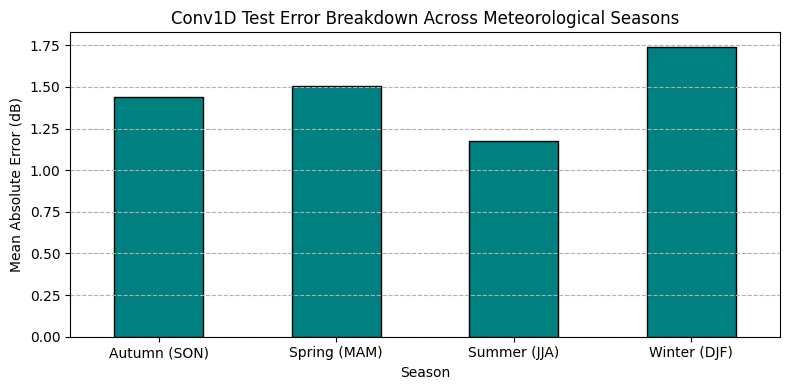

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

print("\n--- RUNNING SEASONAL ERROR ANALYSIS ---")

# 1. Re-extract or align dates for the test set
# Assuming df_sar and X_all were generated in the exact same order:
# We map the test indices back to their corresponding dates
all_dates_list = []
for p_id in df_sar['point_id'].unique():
    p_subset = df_sar[df_sar['point_id'] == p_id].sort_values('date') # Fixed line
    p_data_len = len(p_subset) - SEQ_LENGTH
    if p_data_len > 1:
        # Match the sequence date extraction logic (target is at index i + seq_length)
        p_dates = p_subset['date'].values[SEQ_LENGTH:]
        all_dates_list.extend(p_dates)

all_dates_array = np.array(all_dates_list)
test_dates = all_dates_array[split_idx:] # Align with your 80/20 test split index

# 2. Define Meteorological Season Mapping Function
def get_season(date):
    month = pd.to_datetime(date).month
    if month in [12, 1, 2]: return 'Winter (DJF)'
    elif month in [3, 4, 5]: return 'Spring (MAM)'
    elif month in [6, 7, 8]: return 'Summer (JJA)'
    else: return 'Autumn (SON)'

seasons = [get_season(d) for d in test_dates]

# 3. Build Error DataFrame
error_df = pd.DataFrame({
    'Date': test_dates,
    'Actual': actual_dB,
    'Predicted': conv_dB, # Using your Conv1D dB predictions from the previous step
    'Season': seasons
})
error_df['Absolute_Error'] = np.abs(error_df['Actual'] - error_df['Predicted'])

# 4. Aggregate by Season
seasonal_summary = error_df.groupby('Season')['Absolute_Error'].agg(['mean', 'median', 'count'])
print("\nMean Absolute Error (MAE) by Season:")
print(seasonal_summary)

# 5. Plot Seasonal MAE breakdown
plt.figure(figsize=(8, 4))
seasonal_summary['mean'].plot(kind='bar', color='teal', edgecolor='black')
plt.title('Conv1D Test Error Breakdown Across Meteorological Seasons')
plt.ylabel('Mean Absolute Error (dB)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()